<a href="https://colab.research.google.com/github/ayoudya/Query_Quest/blob/main/Python_Analysis/Ecommerce_Consumer_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df=pd.read_csv('Ecommerce_Consumer_Behavior_Analysis_Data.csv')
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

In [ ]:
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


In [ ]:
df.astype('category').describe()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,744,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,33,8,2,4,3,2,969,24,989,...,10,3,3,5,344,2,2,4,3,14
top,99-945-7193,27,Female,High,Widowed,Bachelor's,High,Oslo,Electronics,$365.88,...,1,High,Desktop,PayPal,8/12/2024,True,False,Need-based,No Preference,1
freq,1,43,452,515,260,341,517,4,54,2,...,111,270,350,219,8,521,509,256,372,86


In [ ]:
desc=df.describe(include='all')
unique_counts=df.nunique()
desc, unique_counts

(        Customer_ID          Age  Gender Income_Level Marital_Status  \
 count          1000  1000.000000    1000         1000           1000   
 unique         1000          NaN       8            2              4   
 top     48-203-9118          NaN  Female         High        Widowed   
 freq              1          NaN     452          515            260   
 mean            NaN    34.304000     NaN          NaN            NaN   
 std             NaN     9.353238     NaN          NaN            NaN   
 min             NaN    18.000000     NaN          NaN            NaN   
 25%             NaN    26.000000     NaN          NaN            NaN   
 50%             NaN    34.500000     NaN          NaN            NaN   
 75%             NaN    42.000000     NaN          NaN            NaN   
 max             NaN    50.000000     NaN          NaN            NaN   
 
        Education_Level Occupation Location Purchase_Category Purchase_Amount  \
 count             1000       1000     10

In [ ]:
missing=df.isnull().sum()
dup_rows=df.duplicated().sum()
missing, dup_rows

(Customer_ID                                0
 Age                                        0
 Gender                                     0
 Income_Level                               0
 Marital_Status                             0
 Education_Level                            0
 Occupation                                 0
 Location                                   0
 Purchase_Category                          0
 Purchase_Amount                            0
 Frequency_of_Purchase                      0
 Purchase_Channel                           0
 Brand_Loyalty                              0
 Product_Rating                             0
 Time_Spent_on_Product_Research(hours)      0
 Social_Media_Influence                   247
 Discount_Sensitivity                       0
 Return_Rate                                0
 Customer_Satisfaction                      0
 Engagement_with_Ads                      256
 Device_Used_for_Shopping                   0
 Payment_Method                   

In [ ]:
df['Age']=pd.to_numeric(df['Age'],errors='coerce')
df['Frequency_of_Purchase ']=pd.to_numeric(df['Frequency_of_Purchase'],errors='coerce')
df['Brand_Loyalty']=pd.to_numeric(df['Brand_Loyalty'],errors='coerce')
df['Product_Rating']=pd.to_numeric(df['Product_Rating'],errors='coerce')
df['Time_Spent_on_Product_Research(hours)']=pd.to_numeric(df['Time_Spent_on_Product_Research(hours)'],errors='coerce')
df['Return_Rate']=pd.to_numeric(df['Return_Rate'],errors='coerce')
df['Customer_Satisfaction']=pd.to_numeric(df['Customer_Satisfaction'],errors='coerce')
df['Time_to_Decision']=pd.to_numeric(df['Time_to_Decision'],errors='coerce')

result={}


result['Customer_ID']=df['Customer_ID'].unique().tolist()
result['Age']=(df['Age'].min(),df['Age'].max())
result['Gender']=df['Gender'].unique().tolist()
result['Income_Level']=df['Income_Level'].unique().tolist()
result['Marital_Status']=df['Marital_Status'].unique().tolist()
result['Education_Level']=df['Education_Level'].unique().tolist()
result['Occupation']=df['Occupation'].unique().tolist()
result['Location']=df['Location'].unique().tolist()
result['Purchase_Category']=df['Purchase_Category'].unique().tolist()
result['Purchase_Amount']=(df['Purchase_Amount'].min(),df['Purchase_Amount'].max())
result['Frequency_of_Purchase']=(df['Frequency_of_Purchase '].min(),df['Frequency_of_Purchase '].max())
result['Purchase_Channel']=df['Purchase_Channel'].unique().tolist()
result['Brand_Loyalty']=(df['Brand_Loyalty'].min(),df['Brand_Loyalty'].max())
result['Product_Rating']=(df['Product_Rating'].min(),df['Product_Rating'].max())
result['Time_Spent_on_Product_Research(hours)']=(df['Time_Spent_on_Product_Research(hours)'].min(),df['Time_Spent_on_Product_Research(hours)'].max())
result['Social_Media_Influence']=df['Social_Media_Influence'].unique().tolist()
result['Discount_Sensitivity']=df['Discount_Sensitivity'].unique().tolist()
result['Return_Rate']=(df['Return_Rate'].min(),df['Return_Rate'].max())
result['Customer_Satisfaction']=(df['Customer_Satisfaction'].min(),df['Customer_Satisfaction'].max())
result['Engagement_with_Ads']=df['Engagement_with_Ads'].unique().tolist()
result['Device_Used_for_Shopping']=df['Device_Used_for_Shopping'].unique().tolist()
result['Payment_Method']=df['Payment_Method'].unique().tolist()
result['Time_of_Purchase']=df['Time_of_Purchase'].unique().tolist()
result['Discount_Used']=df['Discount_Used'].unique().tolist()
result['Customer_Loyalty_Program_Member']=df['Customer_Loyalty_Program_Member'].unique().tolist()
result['Purchase_Intent']=df['Purchase_Intent'].unique().tolist()
result['Shipping_Preference']=df['Shipping_Preference'].unique().tolist()
result['Time_to_Decision']=(df['Time_to_Decision'].min(),df['Time_to_Decision'].max())

result

{'Customer_ID': ['37-611-6911',
  '29-392-9296',
  '84-649-5117',
  '48-980-6078',
  '91-170-9072',
  '82-561-4233',
  '90-144-9193',
  '88-661-4689',
  '37-065-3182',
  '84-894-9222',
  '44-674-4037',
  '78-116-8349',
  '19-933-8095',
  '80-684-5072',
  '23-302-7502',
  '90-069-8934',
  '45-073-7243',
  '89-883-2101',
  '00-477-9449',
  '67-159-7366',
  '85-691-4293',
  '56-085-0464',
  '33-264-2822',
  '95-478-2650',
  '04-349-6759',
  '21-755-8745',
  '29-625-7057',
  '58-623-8404',
  '56-506-4709',
  '25-839-8670',
  '89-194-0596',
  '55-163-1389',
  '28-225-4286',
  '14-305-8712',
  '85-738-6864',
  '17-198-5155',
  '15-354-9904',
  '35-198-9248',
  '03-950-6074',
  '19-999-0134',
  '57-989-1487',
  '07-816-2673',
  '70-761-3550',
  '38-242-3251',
  '95-525-0842',
  '37-101-4922',
  '37-128-5425',
  '27-439-9545',
  '37-126-7954',
  '82-990-0504',
  '21-734-0212',
  '76-148-9413',
  '53-639-3774',
  '20-817-9584',
  '18-655-3670',
  '72-431-5021',
  '07-479-3919',
  '17-032-6274',

**Deskripsi**:

Dataset memiliki 1000 baris dan 28 kolom, mencakup Age, Gender, Income_Level, Occupation, Location, dan Purchase_Category.


**Missing Value**:


*   ```Social_Media_Influence```: memiliki 247 data hilang
*   ```Engagement_with_Ads```: memiliki 256 data hilang


**Duplikat**:

Tidak ada data yang terdupikat.


**Seleksi Variabel**:

Analisis ini berfokus pada pemanfaatan perilaku konsumen untuk memprediksi niat belanja mereka. Hasil prediksi ini akan digunakan untuk mengoptimalkan penargetan iklan dan personalisasi program loyalitas. Sehingga variabel yang akan digunakan antara lain:

Variabel Target (y):
*   ```Purchase_Intent```

Variabel Fitur (X):
*   ```Time_Spent_on_Product_Research```
*   ```Time_to_Decision```
*   ```Social_Media_Influence```
*   ```Discount_Sensitivity```
*   ```Discount_Used```
*   ```Engagement_with_Ads```
*   ```Income_Level```
*   ```Age```
*   ```Customer_Satisfaction```
*   ```Purchase_Category```



In [ ]:
df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '', regex=False)
df['Purchase_Amount'] = pd.to_numeric(df['Purchase_Amount'], errors='coerce')

In [ ]:
result={}

result['Purchase_Intent']=df['Purchase_Intent'].unique().tolist()
result['Time_Spent_on_Product_Research(hours)']=(df['Time_Spent_on_Product_Research(hours)'].min(),df['Time_Spent_on_Product_Research(hours)'].max())
result['Time_to_Decision']=(df['Time_to_Decision'].min(),df['Time_to_Decision'].max())
result['Social_Media_Influence']=df['Social_Media_Influence'].unique().tolist()
result['Discount_Sensitivity']=df['Discount_Sensitivity'].unique().tolist()
result['Discount_Used']=df['Discount_Used'].unique().tolist()
result['Engagement_with_Ads']=df['Engagement_with_Ads'].unique().tolist()
result['Income_Level']=df['Income_Level'].unique().tolist()
result['Age']=(df['Age'].min(),df['Age'].max())
result['Brand_Loyalty']=(df['Brand_Loyalty'].min(),df['Brand_Loyalty'].max())
result['Customer_Satisfaction']=(df['Customer_Satisfaction'].min(),df['Customer_Satisfaction'].max())
result['Purchase_Category']=df['Purchase_Category'].unique().tolist()
result['Purchase_Amount']=(df['Purchase_Amount'].min(),df['Purchase_Amount'].max())

result

{'Purchase_Intent': ['Need-based', 'Wants-based', 'Impulsive', 'Planned'],
 'Time_Spent_on_Product_Research(hours)': (0.0, 2.0),
 'Time_to_Decision': (1, 14),
 'Social_Media_Influence': [nan, 'Medium', 'Low', 'High'],
 'Discount_Sensitivity': ['Somewhat Sensitive',
  'Not Sensitive',
  'Very Sensitive'],
 'Discount_Used': [True, False],
 'Engagement_with_Ads': [nan, 'High', 'Low', 'Medium'],
 'Income_Level': ['Middle', 'High'],
 'Age': (18, 50),
 'Brand_Loyalty': (1, 5),
 'Customer_Satisfaction': (1, 10),
 'Purchase_Category': ['Gardening & Outdoors',
  'Food & Beverages',
  'Office Supplies',
  'Home Appliances',
  'Furniture',
  'Books',
  'Sports & Outdoors',
  'Mobile Accessories',
  'Luxury Goods',
  'Animal Feed',
  'Health Care',
  'Hotels',
  'Packages)',
  'Electronics',
  'Software & Apps',
  'Baby Products',
  'Toys & Games',
  'Arts & Crafts',
  'Health Supplements',
  'Groceries',
  'Clothing',
  'Beauty & Personal Care',
  'Travel & Leisure (Flights',
  'Jewelry & Accesso

In [ ]:
numeric_cols=['Time_Spent_on_Product_Research(hours)', 'Time_to_Decision', 'Age', 'Brand_Loyalty', 'Customer_Satisfaction', 'Purchase_Amount']

outliers={}
for col in numeric_cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  outliers[col]=len(df[(df[col]<lower_bound) | (df[col]>upper_bound)])

outliers

{'Time_Spent_on_Product_Research(hours)': 0,
 'Time_to_Decision': 0,
 'Age': 0,
 'Brand_Loyalty': 0,
 'Customer_Satisfaction': 0,
 'Purchase_Amount': 0}

In [ ]:
missing_values=['nan']
df = df.replace(missing_values, np.nan)

In [ ]:
categoric_cols=['Social_Media_Influence', 'Engagement_with_Ads']
for col in categoric_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Income_Level,0
Marital_Status,0
Education_Level,0
Occupation,0
Location,0
Purchase_Category,0
Purchase_Amount,0


**Deskripsi**:

Nilai ```Purchase_Amount``` telah di bersihkan yang sebelumnya terdapat simbol dollar ($) di hilangkan agar nilai dapat di proses

**Imputasi data**:

Telah dilakukan imputasi data pada variabel

```Social_Media_Influence``` dan ```Engagement_with_Ads``` karena terdapat 'nan' pada data.

**Outliers**:

Tidak ada data nominal yang mengalami outliers



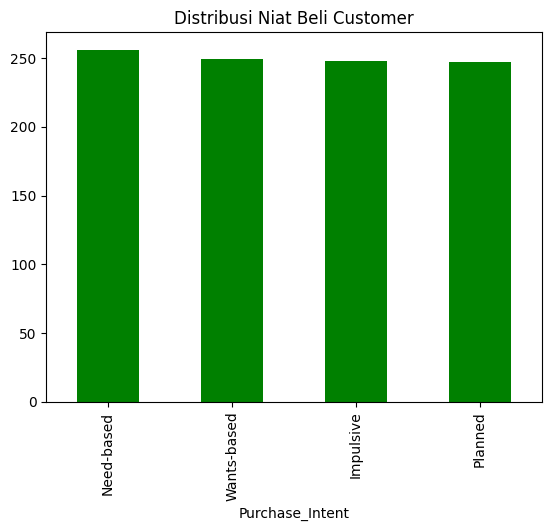

In [ ]:
df['Purchase_Intent'].value_counts().plot(kind='bar', color= 'green', title='Distribusi Niat Beli Customer')
plt.show()

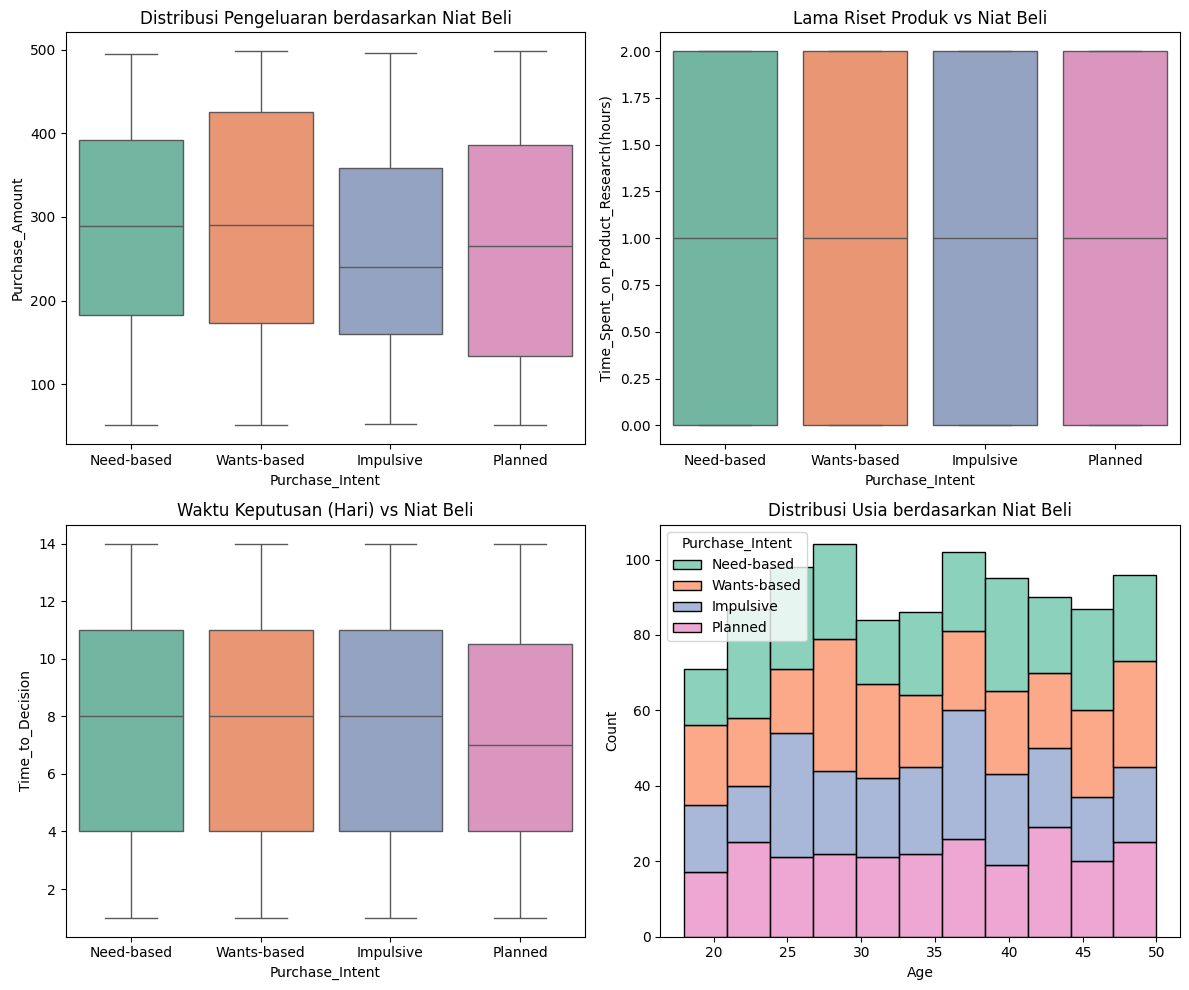

In [ ]:
plt.figure(figsize=(12,10))

# Plot A: Purchase_Amount vs Purchase_Intent [1, 3]
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Purchase_Intent', y='Purchase_Amount', hue='Purchase_Intent', palette='Set2', legend=False)
plt.title('Distribusi Pengeluaran berdasarkan Niat Beli')

# Plot B: Waktu Riset vs Purchase_Intent [1, 3]
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Purchase_Intent', y='Time_Spent_on_Product_Research(hours)', hue='Purchase_Intent', palette='Set2', legend=False)
plt.title('Lama Riset Produk vs Niat Beli')

# Plot C: Waktu Pengambilan Keputusan vs Purchase_Intent [4, 5]
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Purchase_Intent', y='Time_to_Decision', hue='Purchase_Intent', palette='Set2', legend=False)
plt.title('Waktu Keputusan (Hari) vs Niat Beli')

# Plot D: Distribusi Usia terhadap Niat Beli [1, 6]
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Age', hue='Purchase_Intent', multiple="stack", palette='Set2')
plt.title('Distribusi Usia berdasarkan Niat Beli')

plt.tight_layout()
plt.show()

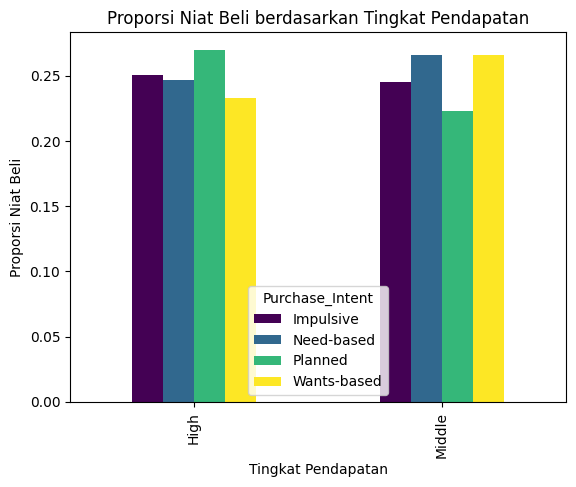

In [ ]:
pd.crosstab(df['Income_Level'], df['Purchase_Intent'], normalize='index').plot(kind='bar', colormap='viridis', title='Proporsi Niat Beli berdasarkan Tingkat Pendapatan')
plt.xlabel('Tingkat Pendapatan')
plt.ylabel('Proporsi Niat Beli')
plt.show()

In [ ]:
numeric_cols = ['Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Time_to_Decision', 'Age', 'Brand_Loyalty', 'Customer_Satisfaction', 'Purchase_Amount']

In [ ]:
df_encoded=pd.get_dummies(df,columns=['Purchase_Intent', 'Social_Media_Influence', 'Discount_Sensitivity', 'Discount_Used', 'Engagement_with_Ads', 'Income_Level', 'Purchase_Category'],drop_first=False)
df_encoded.head()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Occupation,Location,Purchase_Amount,Frequency_of_Purchase,Purchase_Channel,...,Purchase_Category_Hotels,Purchase_Category_Jewelry & Accessories,Purchase_Category_Luxury Goods,Purchase_Category_Mobile Accessories,Purchase_Category_Office Supplies,Purchase_Category_Packages),Purchase_Category_Software & Apps,Purchase_Category_Sports & Outdoors,Purchase_Category_Toys & Games,Purchase_Category_Travel & Leisure (Flights
0,37-611-6911,22,Female,Married,Bachelor's,Middle,Évry,333.80,4,Mixed,...,False,False,False,False,False,False,False,False,False,False
1,29-392-9296,49,Male,Married,High School,High,Huocheng,222.22,11,In-Store,...,False,False,False,False,False,False,False,False,False,False
2,84-649-5117,24,Female,Single,Master's,High,Huzhen,426.22,2,Mixed,...,False,False,False,False,True,False,False,False,False,False
3,48-980-6078,29,Female,Single,Master's,Middle,Wiwilí,101.31,6,Mixed,...,False,False,False,False,False,False,False,False,False,False
4,91-170-9072,33,Female,Widowed,High School,Middle,Nara,211.70,6,Mixed,...,False,False,False,False,False,False,False,False,False,False


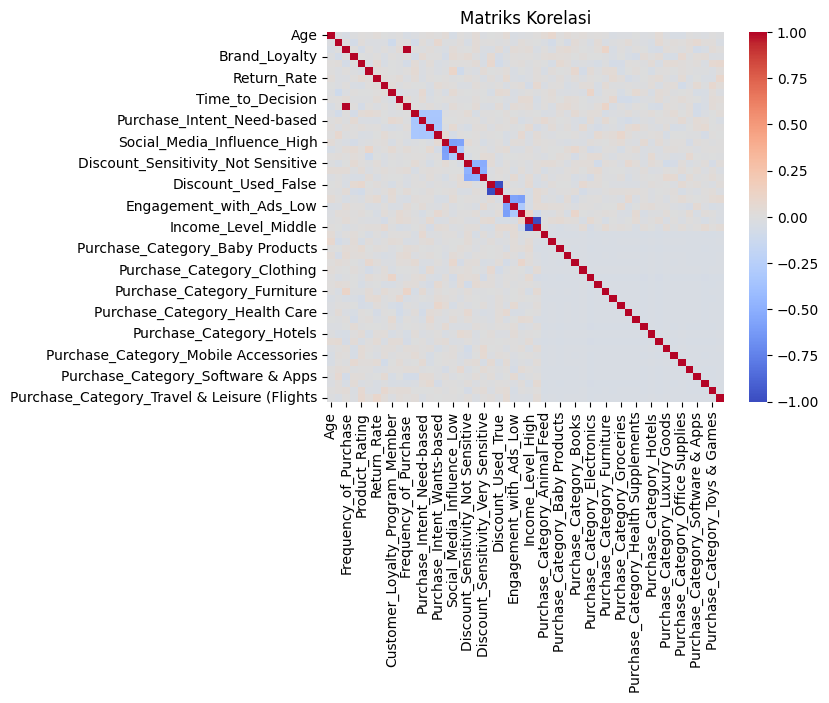

In [ ]:
plt.figure()
sns.heatmap(df_encoded.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi')
plt.show()

**Deskripsi**:

*   **Distribusi Niat Beli**: menunjukkan orang yang membeli dengan niat Need-based, Wants-based, Impulsive, atau Planned memiliki jumlah yang rata sekitar 200-250 orang.
*   **Distribusi Pengeluaran berdasarkan Niat Beli**: menunjukkan bahwa orang yang membeli karena "keinginan" atau "kebutuhan" cenderung mengeluarkan uang lebih banyak daripada mereka yang membeli secara "impulsif" atau tiba-tiba
*   **Lama Riset Produk vs Niat Beli**: lama riset ternyata sangat seragam (sekitar 1 jam) untuk semua jenis niat beli
. Ini menarik karena biasanya pembeli "Planned" (Terencana) risetnya lebih lama, namun data ini menunjukkan perilaku riset yang cukup merata di semua segmen
*   **Waktu Keputusan (Hari) vs Niat Beli**: orang  yang memiliki niat "Terencana" justru memiliki rentang waktu pengambilan keputusan yang lebih stabil (kotaknya lebih pendek), sementara pembeli "Impulsif" memiliki variasi waktu yang sangat luas
*   **Distribusi Usia berdasarkan Niat Beli**: puncak jumlah pelanggan ada di kisaran usia 25-30 tahun dan 35-40 tahun. Pada usia 30-an awal, terlihat warna hijau (Need-based) cukup dominan, artinya kelompok usia ini banyak belanja karena faktor kebutuhan
*   **Proporsi Niat Beli berdasarkan Tingkat Pendapatan**: pada pendapatan tingkat tengah orang mengeluarkan uang untuk "kebutuhan" dan "keinginan" sedangkan pada pendapatan tingkat tinggi orang mengeluarkan uang lebih banyak untuk "planned" dan "impulsif". Dimana hal ini sangat berbanding terbalik.
*   **Matriks Korelasi**: untuk setiap variabel memiliki hubungan dengan keunikannya tersendiri dan tidak ada hubungan antar variabel yang terlalu erat










In [ ]:
X_numerik = df_encoded[['Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Time_to_Decision', 'Age', 'Brand_Loyalty', 'Customer_Satisfaction', 'Purchase_Amount']]
X_kategorik = df_encoded.filter(regex='Social_Media_Influence_|Discount_Sensitivity_|Discount_Used_|Engagement_with_Ads_|Income_Level_|Purchase_Category')

X = pd.concat([X_numerik, X_kategorik], axis=1)
y = df['Purchase_Intent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

importances=model.feature_importances_
for feature, score in zip (X.columns, importances):
  print(f'Fitur: {feature}, Skor Kepentingan: {score:.4f}')

Fitur: Product_Rating, Skor Kepentingan: 0.0579
Fitur: Time_Spent_on_Product_Research(hours), Skor Kepentingan: 0.0485
Fitur: Time_to_Decision, Skor Kepentingan: 0.0734
Fitur: Age, Skor Kepentingan: 0.1096
Fitur: Brand_Loyalty, Skor Kepentingan: 0.0648
Fitur: Customer_Satisfaction, Skor Kepentingan: 0.0753
Fitur: Purchase_Amount, Skor Kepentingan: 0.1609
Fitur: Social_Media_Influence_High, Skor Kepentingan: 0.0282
Fitur: Social_Media_Influence_Low, Skor Kepentingan: 0.0194
Fitur: Social_Media_Influence_Medium, Skor Kepentingan: 0.0130
Fitur: Discount_Sensitivity_Not Sensitive, Skor Kepentingan: 0.0312
Fitur: Discount_Sensitivity_Somewhat Sensitive, Skor Kepentingan: 0.0212
Fitur: Discount_Sensitivity_Very Sensitive, Skor Kepentingan: 0.0217
Fitur: Discount_Used_False, Skor Kepentingan: 0.0218
Fitur: Discount_Used_True, Skor Kepentingan: 0.0198
Fitur: Engagement_with_Ads_High, Skor Kepentingan: 0.0220
Fitur: Engagement_with_Ads_Low, Skor Kepentingan: 0.0221
Fitur: Engagement_with_Ads_Me

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred_cont = model.predict(X_test_scaled)

X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_df['Purchase_Intent_actual'] = y_test.values
X_test_df['Purchase_Intent_pred'] = y_pred_cont

X_test_df.head()

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred_cont)
print(f'Akurasi: {accuracy:.2f}')
print(classification_report(y_test, y_pred_cont))

Akurasi: 0.28
              precision    recall  f1-score   support

   Impulsive       0.31      0.38      0.34        52
  Need-based       0.24      0.39      0.30        46
     Planned       0.35      0.17      0.23        54
 Wants-based       0.24      0.17      0.20        48

    accuracy                           0.28       200
   macro avg       0.28      0.28      0.27       200
weighted avg       0.29      0.28      0.27       200



**Deskripsi**:

Hasil menunjukkan akurasi yang sangat rendah yaitu 28%. Untuk mencapai akurasi tinggi diperlukan tunning data

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Change to RandomForestClassifier for classification task
rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_tuned)
conf_matrix = confusion_matrix(y_test, y_pred_tuned)
class_report = classification_report(y_test, y_pred_tuned)

print(f'\nEvaluation of the tuned model on the test set:')
print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best accuracy score:  0.2650070870059043

Evaluation of the tuned model on the test set:
Accuracy: 0.31
Confusion Matrix:
[[17 14  9 12]
 [12 19 11  4]
 [11 18 15 10]
 [10 24  3 11]]
Classification Report:
              precision    recall  f1-score   support

   Impulsive       0.34      0.33      0.33        52
  Need-based       0.25      0.41      0.31        46
     Planned       0.39      0.28      0.33        54
 Wants-based       0.30      0.23      0.26        48

    accuracy                           0.31       200
   macro avg       0.32      0.31      0.31       200
weighted avg       0.32      0.31      0.31       200



**Deskripsi**:

Setelah dilakukan tunning data, didapat nilai accuracy maksimal hanya mencapai 31%. Hal ini belum mencapai titik aman untuk model. Langkah selanjutnya memperluas variabel fitur (X). Variabel yang akan ditambahkan antara lain:

* ```Frequency_of_Purchase```: untuk melihat perbedaan antara pembeli dengan frekuensi yang stabil atau pembeli yang tidak (impulsif)
* ```Return_Rate```: untuk melihat keterkaitan antara pembeli melakukan retur dengan niat beli
* ```Gender```: untuk melihat pola belanja antara laki-laki dan perempuan
* ```Marital_Status```: untuk melihat pengaruh antara seseorang membeli karena kebutuhan atau impulsif
* ```Occupation```:untuk melihat pengaruh antara seseorang membeli karena kebutuhan atau impulsif
* ```Customer_Loyalty_Program_Member```: untuk melihat loyalitas pembeli dengan member atau non-member







In [ ]:
df_encoded_add =pd.get_dummies(df,columns=['Purchase_Intent', 'Social_Media_Influence', 'Discount_Sensitivity', 'Discount_Used', 'Engagement_with_Ads', 'Income_Level', 'Purchase_Category', 'Gender', 'Marital_Status', 'Occupation', 'Customer_Loyalty_Program_Member'],drop_first=False)

X_numerik_add = df_encoded[['Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Time_to_Decision', 'Age', 'Brand_Loyalty', 'Customer_Satisfaction', 'Purchase_Amount', 'Frequency_of_Purchase', 'Return_Rate']]
X_kategorik_add = df_encoded.filter(regex='Social_Media_Influence_|Discount_Sensitivity_|Discount_Used_|Engagement_with_Ads_|Income_Level_|Purchase_Category_|Gender_|Marital_Status_|Occupation_|Customer_Loyalty_Program_Member')

X_add = pd.concat([X_numerik_add, X_kategorik_add], axis=1)
y_add = df['Purchase_Intent']

X_add_train, X_add_test, y_add_train, y_add_test = train_test_split(X_add, y_add, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_add_train_scaled = scaler.fit_transform(X_add_train)
X_add_test_scaled = scaler.transform(X_add_test)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)
model.fit(X_add_train_scaled, y_add_train)

y_add_pred_cont = model.predict(X_add_test_scaled)

X_add_test_df = pd.DataFrame(X_add_test, columns=X.columns)
X_add_test_df['Purchase_Intent_actual'] = y_add_test.values
X_add_test_df['Purchase_Intent_pred'] = y_add_pred_cont

X_add_test_df.head()

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_add_test, y_add_pred_cont)
print(f'Akurasi: {accuracy:.2f}')
print(classification_report(y_add_test, y_add_pred_cont))

Akurasi: 0.28
              precision    recall  f1-score   support

   Impulsive       0.31      0.29      0.30        52
  Need-based       0.25      0.48      0.33        46
     Planned       0.28      0.17      0.21        54
 Wants-based       0.30      0.19      0.23        48

    accuracy                           0.28       200
   macro avg       0.28      0.28      0.27       200
weighted avg       0.28      0.28      0.26       200



In [ ]:
result={}

result['Frequency_of_Purchase']=(df['Frequency_of_Purchase'].min(),df['Frequency_of_Purchase'].max())
result['Return_Rate']=(df['Return_Rate'].min(),df['Return_Rate'].max())
result['Gender']=df['Gender'].unique().tolist()
result['Marital_Status']=df['Marital_Status'].unique().tolist()
result['Occupation']=df['Occupation'].unique().tolist()
result['Customer_Loyalty_Program_Member']=df['Customer_Loyalty_Program_Member'].unique().tolist()
result

{'Frequency_of_Purchase': (2, 12),
 'Return_Rate': (0, 2),
 'Gender': ['Female',
  'Male',
  'Bigender',
  'Genderfluid',
  'Non-binary',
  'Polygender',
  'Agender',
  'Genderqueer'],
 'Marital_Status': ['Married', 'Single', 'Widowed', 'Divorced'],
 'Occupation': ['Middle', 'High'],
 'Customer_Loyalty_Program_Member': [False, True]}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y=df['Purchase_Intent']

#model logstic regression
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

#model random forest
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

#prediksi
y_pred_log=log_reg.predict(X_test)
y_pred_rf=rf.predict(X_test)

print('Logstic Regression Accuracy:', accuracy_score(y_test, y_pred_log))
print('Classification Report:\n', classification_report(y_test, y_pred_log))
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Classification Report:\n', classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logstic Regression Accuracy: 0.245
Classification Report:
               precision    recall  f1-score   support

   Impulsive       0.27      0.27      0.27        52
  Need-based       0.25      0.30      0.27        46
     Planned       0.24      0.17      0.20        54
 Wants-based       0.22      0.25      0.24        48

    accuracy                           0.24       200
   macro avg       0.24      0.25      0.24       200
weighted avg       0.25      0.24      0.24       200

Random Forest Accuracy: 0.285
Classification Report:
               precision    recall  f1-score   support

   Impulsive       0.31      0.29      0.30        52
  Need-based       0.27      0.41      0.32        46
     Planned       0.29      0.22      0.25        54
 Wants-based       0.28      0.23      0.25        48

    accuracy                           0.28       200
   macro avg       0.29      0.29      0.28       200
weighted avg       0.29      0.28      0.28       200



<function matplotlib.pyplot.show(close=None, block=None)>

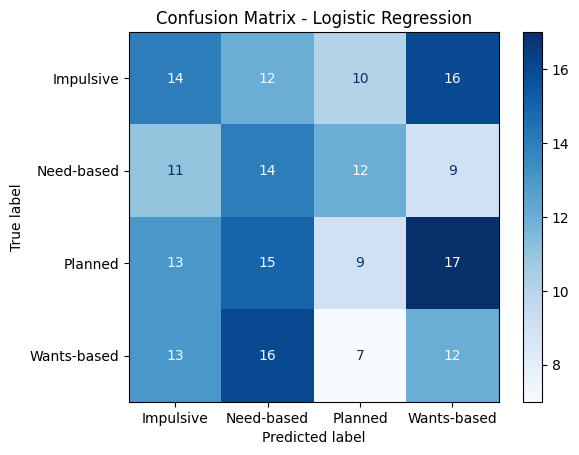

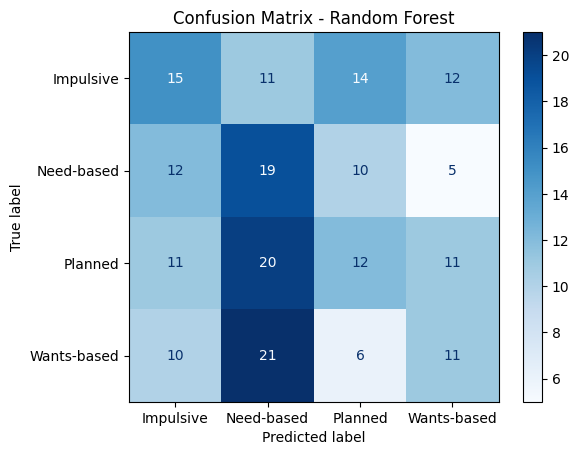

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log=confusion_matrix(y_test, y_pred_log)
disp_log=ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_reg.classes_)
disp_log.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.show

cm_rf=confusion_matrix(y_test, y_pred_rf)
disp_rf=ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest')
plt.show

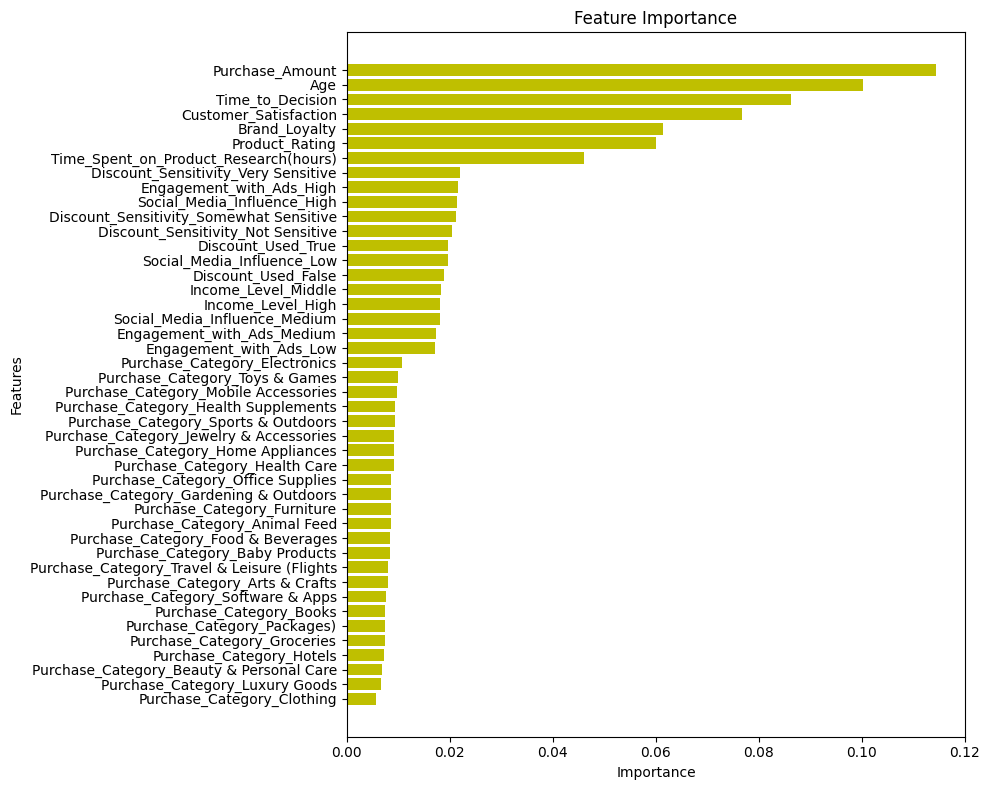

In [ ]:
features_names=X.columns
importances=rf.feature_importances_
indices=np.argsort(importances)

plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices], color='y', align='center')
plt.yticks(range(len(indices)), [features_names[i] for i in indices])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
df_final=df.copy()
csv_path='Final_Ecommerce_Consumer_Behavior_Analysis.csv'
df_final.to_csv(csv_path,index=False)